# 🚂 Sysslan IT Solutions — Internship Project
## Level 6: Final Data Science Project
### Train Route Analysis & Journey Time Prediction System
**Project:** Complete End-to-End Data Science Pipeline  
**Level:** 6 — Final Integration  
**Dataset:** Indian Railways Train Schedule  

---
### 📌 Project Overview
This notebook integrates all previous levels into a **complete journey time prediction system**:
- ✅ Level 1: Data Overview
- ✅ Level 2: Data Cleaning & Feature Engineering  
- ✅ Level 3: Exploratory Data Analysis
- ✅ Level 4: Visualization & Pattern Analysis
- ✅ Level 5: Linear Regression Model
- ✅ Level 6: Final Integrated System + Actual vs Predicted Visualization
---

## 📦 Step 0: Import All Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 11

print('✅ All libraries imported!')

✅ All libraries imported!


---
## ⚙️ STEP 1 — Data Loading & Cleaning (Level 1 + 2)

In [2]:
# ── Load raw dataset ──
df = pd.read_csv('Dataset1.csv')
df['Station_Name']   = df['Station_Name'].str.strip()
df['Station_Code']   = df['Station_Code'].str.strip()
df['Arrival_time']   = df['Arrival_time'].str.strip()
df['Departure_Time'] = df['Departure_Time'].str.strip()
df = df.drop_duplicates()

print(f'✅ Raw data loaded   : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'   Unique Trains     : {df["Train_No"].nunique():,}')
print(f'   Unique Stations   : {df["Station_Code"].nunique():,}')
print(f'   Missing Values    : {df.isnull().sum().sum()}')

✅ Raw data loaded   : 186,074 rows × 12 cols
   Unique Trains     : 11,113
   Unique Stations   : 8,147
   Missing Values    : 0


In [3]:
# ── Time parsing ──
def parse_time_to_minutes(time_str):
    try:
        parts = str(time_str).strip().split(':')
        h = int(parts[0]); m = int(parts[1]); s = int(parts[2]) if len(parts) > 2 else 0
        return h * 60 + m + s / 60
    except:
        return None

df['Arrival_Minutes']   = df['Arrival_time'].apply(parse_time_to_minutes)
df['Departure_Minutes'] = df['Departure_Time'].apply(parse_time_to_minutes)

# ── Journey Duration per train (midnight crossover handled) ──
def calculate_journey_duration(train_group):
    train_group = train_group.sort_values('SN')
    dep_min = train_group.iloc[0]['Departure_Minutes']
    arr_min = train_group.iloc[-1]['Arrival_Minutes']
    if pd.isna(dep_min) or pd.isna(arr_min): return None
    duration = arr_min - dep_min
    if duration < 0: duration += 24 * 60
    return round(duration, 2)

journey_duration = df.groupby('Train_No').apply(calculate_journey_duration).reset_index()
journey_duration.columns = ['Train_No', 'Journey_Duration_Min']
journey_duration = journey_duration.dropna(subset=['Journey_Duration_Min'])
journey_duration['Journey_Duration_Hrs'] = (journey_duration['Journey_Duration_Min'] / 60).round(2)

# ── Feature Engineering ──
total_distance = df.groupby('Train_No')['Distance'].max().reset_index()
total_distance.columns = ['Train_No', 'Total_Distance_km']

num_stops = df.groupby('Train_No')['Station_Code'].count().reset_index()
num_stops.columns = ['Train_No', 'Num_Stops']

route_info = df.sort_values('SN').groupby('Train_No').agg(
    Source_Station=('Station_Name', 'first'),
    Source_Code=('Station_Code', 'first'),
    Destination_Station=('Station_Name', 'last'),
    Destination_Code=('Station_Code', 'last'),
).reset_index()

# ── Master DataFrame ──
train_master = journey_duration \
    .merge(total_distance, on='Train_No') \
    .merge(num_stops, on='Train_No') \
    .merge(route_info, on='Train_No')

train_master['Avg_Speed_kmh'] = (
    train_master['Total_Distance_km'] / train_master['Journey_Duration_Hrs']
).round(2)

# ── Remove outliers ──
train_master = train_master[
    (train_master['Journey_Duration_Min'] >= 5) &
    (train_master['Journey_Duration_Hrs'] <= 100) &
    (train_master['Avg_Speed_kmh'] > 0) &
    (train_master['Avg_Speed_kmh'] <= 250)
].reset_index(drop=True)

print(f'✅ Feature engineering done!')
print(f'   Clean trains      : {len(train_master):,}')
print(f'   Avg Duration      : {train_master["Journey_Duration_Hrs"].mean():.2f} hrs')
print(f'   Avg Distance      : {train_master["Total_Distance_km"].mean():.2f} km')
print(f'   Avg Stops         : {train_master["Num_Stops"].mean():.2f}')

✅ Feature engineering done!
   Clean trains      : 10,625
   Avg Duration      : 4.64 hrs
   Avg Distance      : 280.02 km
   Avg Stops         : 16.19


C:\Users\spr49\AppData\Local\Temp\ipykernel_39696\1465725230.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  journey_duration = df.groupby('Train_No').apply(calculate_journey_duration).reset_index()


---
## 🔍 STEP 2 — EDA Snapshot (Level 3)

In [4]:
# Station traffic
station_traffic = df.groupby(['Station_Code', 'Station_Name'])['Train_No'] \
    .nunique().reset_index()
station_traffic.columns = ['Station_Code', 'Station_Name', 'Train_Count']
station_traffic = station_traffic.sort_values('Train_Count', ascending=False).reset_index(drop=True)

# Correlations
corr_dist  = train_master['Total_Distance_km'].corr(train_master['Journey_Duration_Min'])
corr_stops = train_master['Num_Stops'].corr(train_master['Journey_Duration_Min'])

# Duration categories
def duration_category(hrs):
    if hrs <= 2:    return 'Short (≤2 hrs)'
    elif hrs <= 8:  return 'Medium (2–8 hrs)'
    elif hrs <= 18: return 'Long (8–18 hrs)'
    else:           return 'Very Long (>18 hrs)'

train_master['Duration_Category'] = train_master['Journey_Duration_Hrs'].apply(duration_category)

print('📊 EDA Snapshot:')
print('=' * 50)
print(f'  Corr Distance vs Duration  : {corr_dist:.4f}')
print(f'  Corr Stops    vs Duration  : {corr_stops:.4f}')
print(f'  Busiest Station            : {station_traffic.iloc[0]["Station_Name"]} ({station_traffic.iloc[0]["Train_Count"]} trains)')
print(f'  Duration Categories:')
for cat, cnt in train_master['Duration_Category'].value_counts().items():
    print(f'    {cat:<22} : {cnt:,} trains')

📊 EDA Snapshot:
  Corr Distance vs Duration  : 0.8025
  Corr Stops    vs Duration  : 0.5406
  Busiest Station            : CST-MUMBAI (1027 trains)
  Duration Categories:
    Short (≤2 hrs)         : 5,184 trains
    Medium (2–8 hrs)       : 3,339 trains
    Long (8–18 hrs)        : 1,661 trains
    Very Long (>18 hrs)    : 441 trains


---
## 🤖 STEP 3 — Build & Evaluate Model (Level 5)

In [5]:
# Features & Target
X = train_master[['Total_Distance_km', 'Num_Stops']]
y = train_master['Journey_Duration_Min']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
cv   = cross_val_score(model, X, y, cv=5, scoring='r2')

print('✅ Model Trained & Evaluated!')
print('=' * 50)
print(f'  Algorithm   : Linear Regression')
print(f'  Train Size  : {len(X_train):,}   Test Size: {len(X_test):,}')
print(f'  MAE         : {mae:.2f} min ({mae/60:.2f} hrs)')
print(f'  RMSE        : {rmse:.2f} min ({rmse/60:.2f} hrs)')
print(f'  R² Score    : {r2:.4f} ({r2*100:.1f}% variance explained)')
print(f'  CV R² Mean  : {cv.mean():.4f} ± {cv.std():.4f}')
print()
print(f'  Model Equation:')
print(f'  Duration(min) = {model.intercept_:.2f} + {model.coef_[0]:.4f}×Distance + {model.coef_[1]:.4f}×Stops')

✅ Model Trained & Evaluated!
  Algorithm   : Linear Regression
  Train Size  : 8,500   Test Size: 2,125
  MAE         : 116.93 min (1.95 hrs)
  RMSE        : 180.21 min (3.00 hrs)
  R² Score    : 0.7058 (70.6% variance explained)
  CV R² Mean  : 0.3220 ± 0.4920

  Model Equation:
  Duration(min) = 53.18 + 0.4733×Distance + 5.8191×Stops


---
## 📊 STEP 4 — Final Master Dashboard (Level 6 Core Task)

C:\Users\spr49\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128642 (\N{STEAM LOCOMOTIVE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\spr49\AppData\Local\Temp\ipykernel_39696\1881198419.py:100: UserWarning: Glyph 128642 (\N{STEAM LOCOMOTIVE}) missing from font(s) Arial.
  plt.savefig('Level6_Final_Dashboard.png', dpi=150, bbox_inches='tight',
C:\Users\spr49\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128642 (\N{STEAM LOCOMOTIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


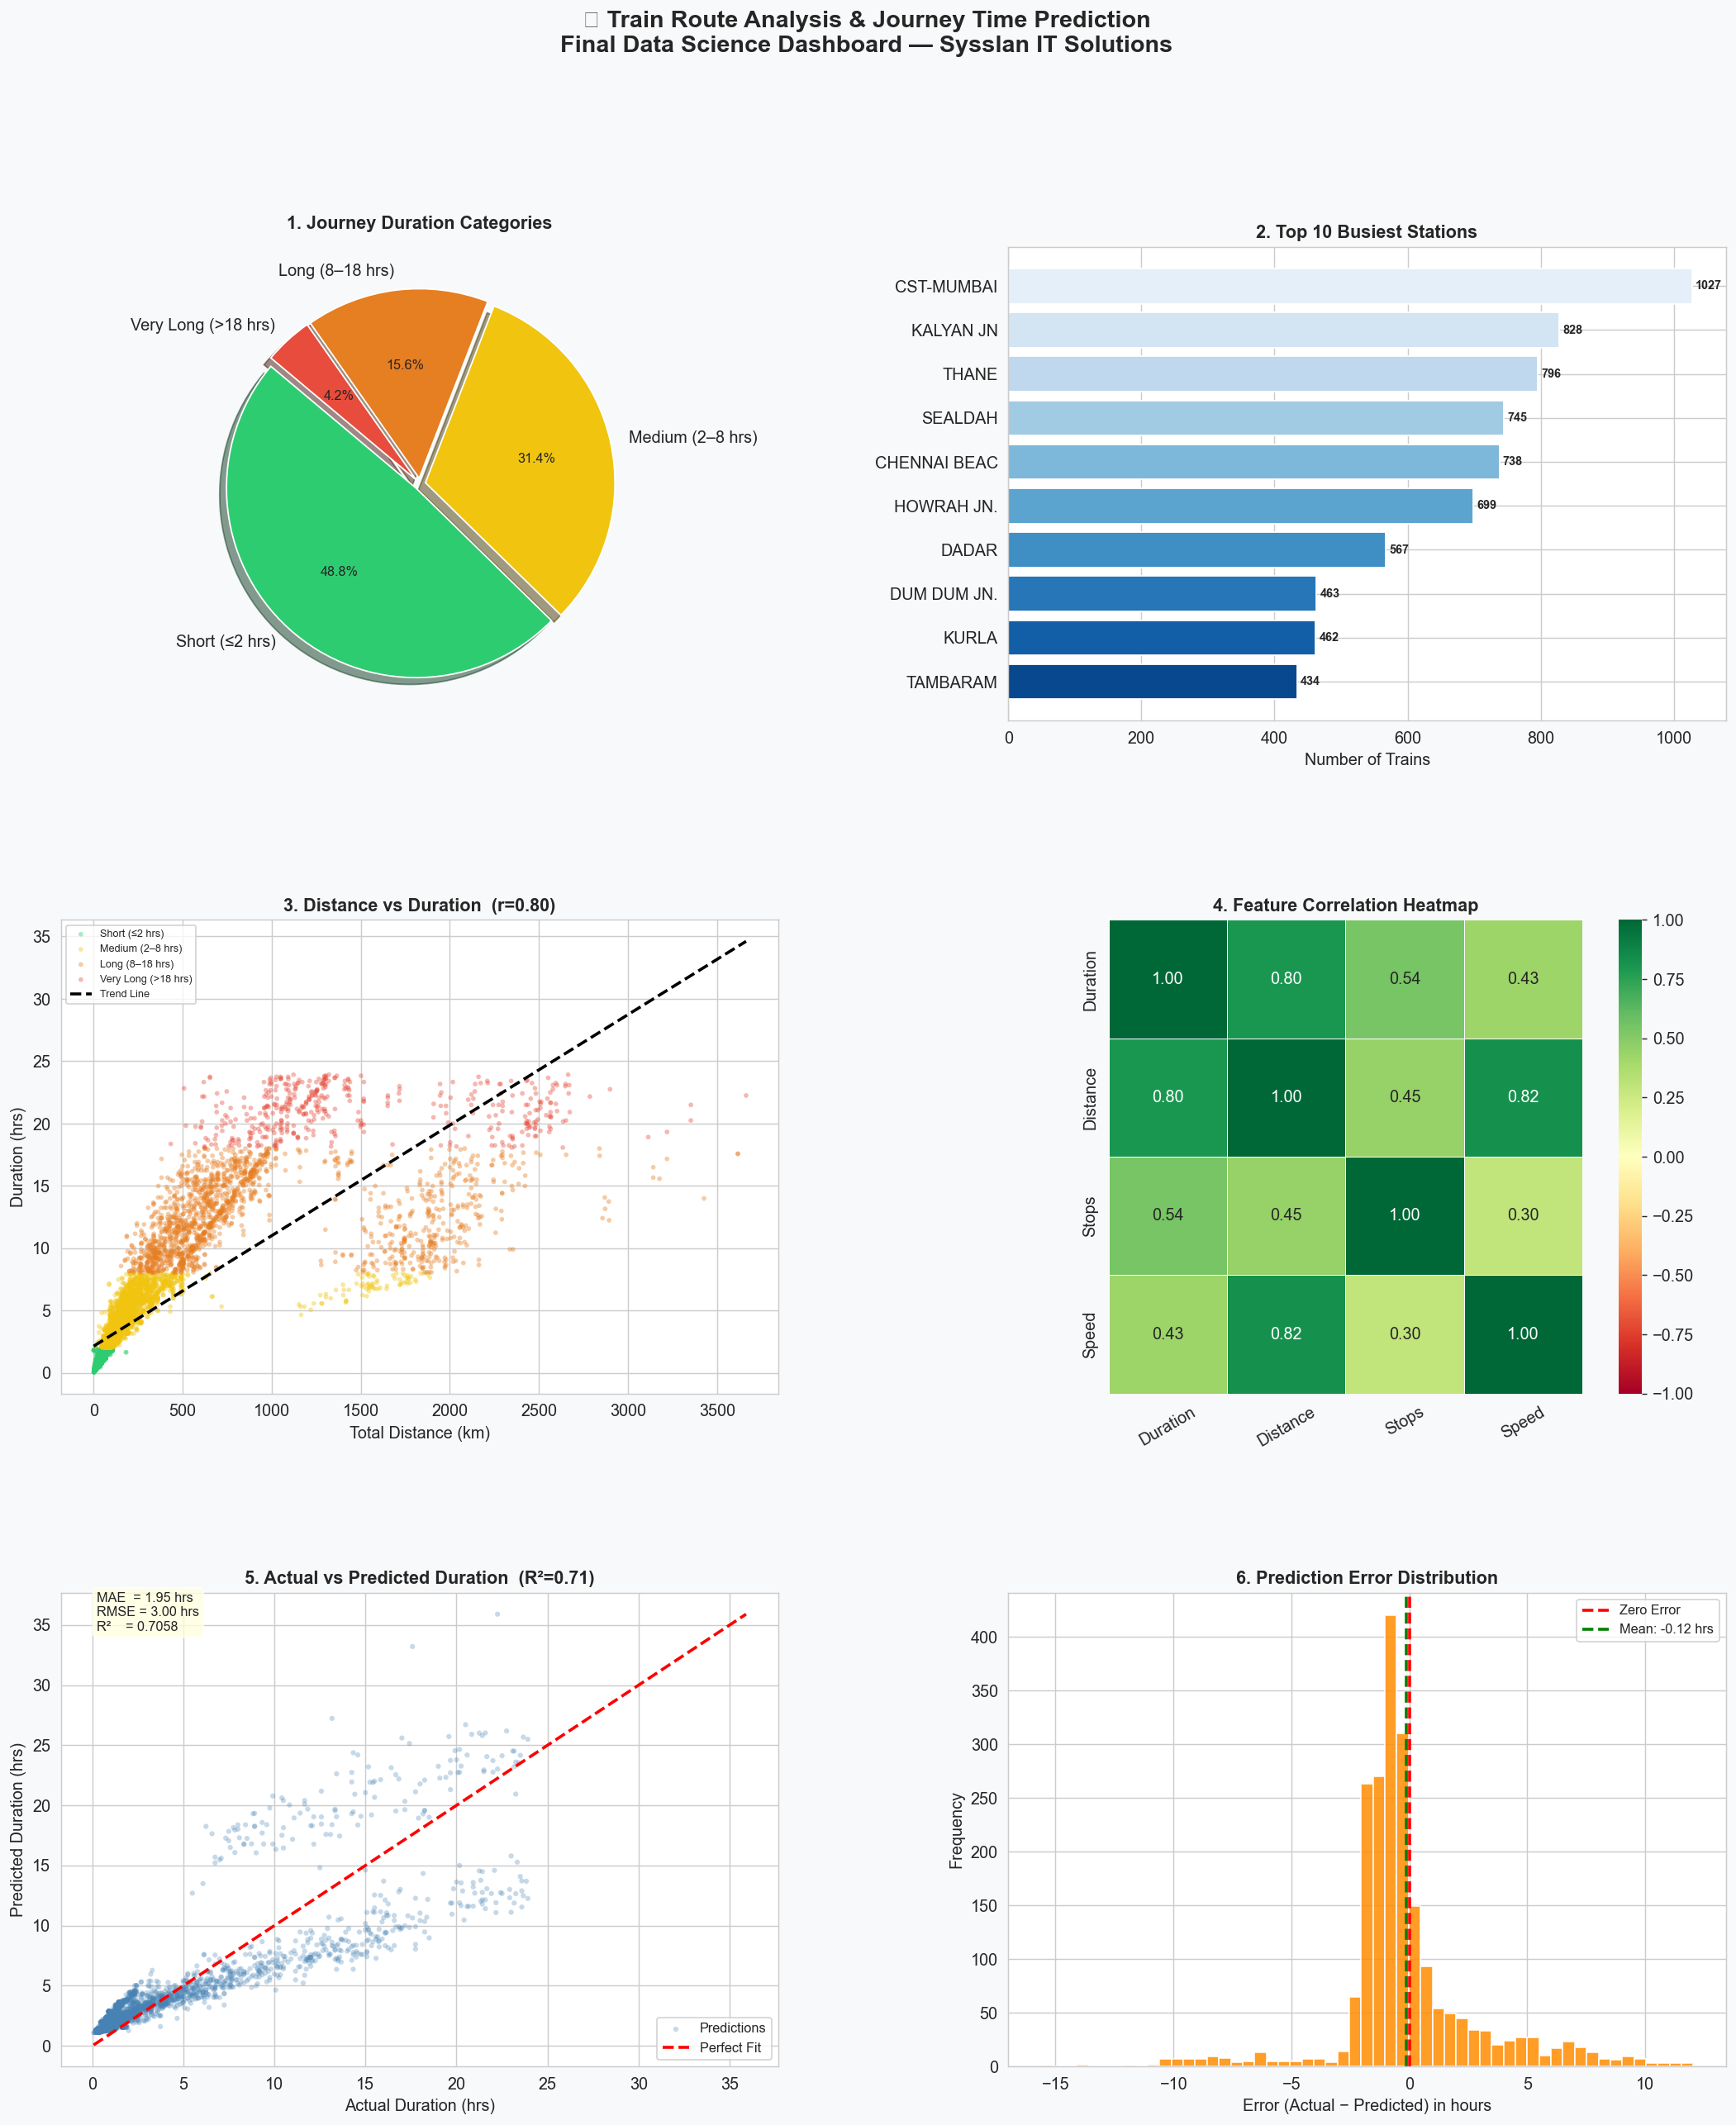

✅ Final Dashboard saved as Level6_Final_Dashboard.png


In [6]:
# ════════════════════════════════════════
# FINAL DASHBOARD — 6 charts in one figure
# ════════════════════════════════════════

cat_order  = ['Short (≤2 hrs)', 'Medium (2–8 hrs)', 'Long (8–18 hrs)', 'Very Long (>18 hrs)']
cat_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
cat_counts = train_master['Duration_Category'].value_counts().reindex(cat_order)

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#f8f9fa')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

fig.suptitle(
    '🚂 Train Route Analysis & Journey Time Prediction\nFinal Data Science Dashboard — Sysslan IT Solutions',
    fontsize=16, fontweight='bold', y=0.98
)

# ── Chart 1: Duration Category Pie ──
ax1 = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax1.pie(
    cat_counts, labels=cat_counts.index,
    autopct='%1.1f%%', colors=cat_colors,
    startangle=140, explode=[0.03]*4, shadow=True
)
for at in autotexts: at.set_fontsize(9)
ax1.set_title('1. Journey Duration Categories', fontweight='bold', fontsize=12, pad=12)

# ── Chart 2: Top 10 Busiest Stations ──
ax2 = fig.add_subplot(gs[0, 1])
top10 = station_traffic.head(10)
colors_bar = sns.color_palette('Blues_r', 10)
ax2.barh(top10['Station_Name'][::-1], top10['Train_Count'][::-1],
         color=colors_bar, edgecolor='white')
ax2.set_title('2. Top 10 Busiest Stations', fontweight='bold', fontsize=12)
ax2.set_xlabel('Number of Trains')
for i, v in enumerate(top10['Train_Count'][::-1]):
    ax2.text(v + 5, i, str(v), va='center', fontsize=8, fontweight='bold')

# ── Chart 3: Distance vs Duration Scatter ──
ax3 = fig.add_subplot(gs[1, 0])
color_map = {
    'Short (≤2 hrs)': '#2ecc71', 'Medium (2–8 hrs)': '#f1c40f',
    'Long (8–18 hrs)': '#e67e22', 'Very Long (>18 hrs)': '#e74c3c'
}
for cat, col in color_map.items():
    sub = train_master[train_master['Duration_Category'] == cat]
    ax3.scatter(sub['Total_Distance_km'], sub['Journey_Duration_Hrs'],
                c=col, label=cat, alpha=0.4, s=10, edgecolors='none')
z = np.polyfit(train_master['Total_Distance_km'], train_master['Journey_Duration_Hrs'], 1)
x_l = np.linspace(0, train_master['Total_Distance_km'].max(), 200)
ax3.plot(x_l, np.poly1d(z)(x_l), 'k--', linewidth=2, label='Trend Line')
ax3.set_title(f'3. Distance vs Duration  (r={corr_dist:.2f})', fontweight='bold', fontsize=12)
ax3.set_xlabel('Total Distance (km)')
ax3.set_ylabel('Duration (hrs)')
ax3.legend(fontsize=7, loc='upper left')

# ── Chart 4: Correlation Heatmap ──
ax4 = fig.add_subplot(gs[1, 1])
corr_cols = ['Journey_Duration_Min', 'Total_Distance_km', 'Num_Stops', 'Avg_Speed_kmh']
corr_labels = ['Duration', 'Distance', 'Stops', 'Speed']
corr_matrix = train_master[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax4,
    annot_kws={'size': 11}
)
ax4.set_title('4. Feature Correlation Heatmap', fontweight='bold', fontsize=12)
ax4.tick_params(axis='x', rotation=30)

# ── Chart 5: Actual vs Predicted (CORE Level 6 Task) ──
ax5 = fig.add_subplot(gs[2, 0])
ax5.scatter(y_test / 60, y_pred / 60, alpha=0.3, s=12,
            color='steelblue', edgecolors='none', label='Predictions')
min_v = min((y_test / 60).min(), (y_pred / 60).min())
max_v = max((y_test / 60).max(), (y_pred / 60).max())
ax5.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Fit')
ax5.set_title(f'5. Actual vs Predicted Duration  (R²={r2:.2f})', fontweight='bold', fontsize=12)
ax5.set_xlabel('Actual Duration (hrs)')
ax5.set_ylabel('Predicted Duration (hrs)')
ax5.legend(fontsize=9)
ax5.text(0.05, 0.92, f'MAE  = {mae/60:.2f} hrs\nRMSE = {rmse/60:.2f} hrs\nR²    = {r2:.4f}',
         transform=ax5.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Chart 6: Residual Distribution ──
ax6 = fig.add_subplot(gs[2, 1])
residuals = (y_test - y_pred) / 60
ax6.hist(residuals, bins=55, color='darkorange', edgecolor='white', alpha=0.85)
ax6.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax6.axvline(residuals.mean(), color='green', linestyle='--',
            linewidth=2, label=f'Mean: {residuals.mean():.2f} hrs')
ax6.set_title('6. Prediction Error Distribution', fontweight='bold', fontsize=12)
ax6.set_xlabel('Error (Actual − Predicted) in hours')
ax6.set_ylabel('Frequency')
ax6.legend(fontsize=9)

plt.savefig('Level6_Final_Dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Final Dashboard saved as Level6_Final_Dashboard.png')

---
## 🔮 STEP 5 — Interactive Prediction System (Task 6.1 Core)

In [7]:
# ══════════════════════════════════════════════════
# JOURNEY TIME PREDICTION SYSTEM
# Input: Distance + Stops → Output: Predicted Time
# ══════════════════════════════════════════════════

def predict_journey_time(distance_km, num_stops):
    """
    Predicts journey duration for a given distance and number of stops.
    Returns duration in minutes and hours.
    """
    input_data = pd.DataFrame({
        'Total_Distance_km': [distance_km],
        'Num_Stops'        : [num_stops]
    })
    pred_min = model.predict(input_data)[0]
    pred_hrs = pred_min / 60
    h = int(pred_hrs)
    m = int((pred_hrs - h) * 60)
    return pred_min, pred_hrs, h, m

# ── Test the prediction system ──
test_cases = [
    (78,   4,  'Short Local Train'),
    (340,  12, 'Medium Route'),
    (978,  22, 'Long Express Train'),
    (1600, 35, 'Very Long Superfast'),
    (2800, 50, 'Cross-Country Train'),
]

print('🚂 JOURNEY TIME PREDICTION SYSTEM')
print('=' * 70)
print(f'{"Route Type":<25} {"Distance":>10} {"Stops":>7} {"Predicted Time":>18}')
print('-' * 70)
for dist, stops, label in test_cases:
    pred_min, pred_hrs, h, m = predict_journey_time(dist, stops)
    print(f'{label:<25} {dist:>8} km {stops:>5} stops   {h:>3}h {m:>2}m  ({pred_hrs:.2f} hrs)')
print('=' * 70)
print()
print('✅ Prediction system working correctly!')

🚂 JOURNEY TIME PREDICTION SYSTEM
Route Type                  Distance   Stops     Predicted Time
----------------------------------------------------------------------
Short Local Train               78 km     4 stops     1h 53m  (1.89 hrs)
Medium Route                   340 km    12 stops     4h 43m  (4.73 hrs)
Long Express Train             978 km    22 stops    10h 44m  (10.74 hrs)
Very Long Superfast           1600 km    35 stops    16h 54m  (16.90 hrs)
Cross-Country Train           2800 km    50 stops    27h 49m  (27.82 hrs)

✅ Prediction system working correctly!


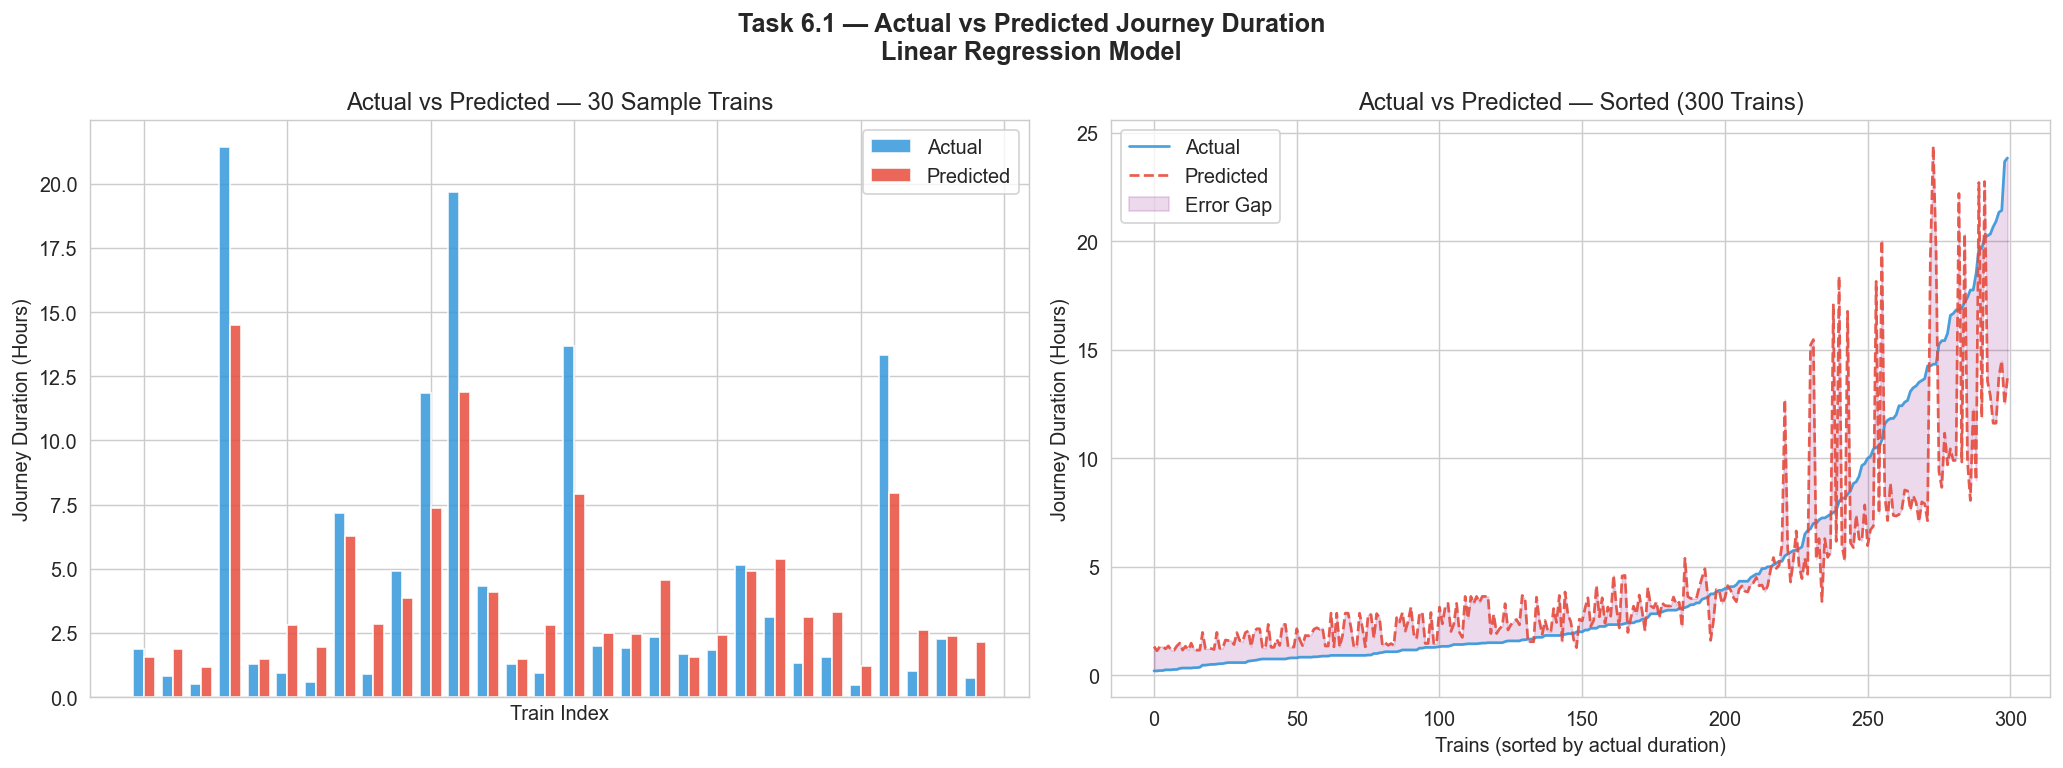

✅ Actual vs Predicted chart saved!


In [8]:
# ── Actual vs Predicted — Detailed Visualization (Core Task 6.1) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Task 6.1 — Actual vs Predicted Journey Duration\nLinear Regression Model',
             fontsize=14, fontweight='bold')

# Sample 300 trains for cleaner visualization
sample_idx = np.random.choice(len(y_test), size=300, replace=False)
y_test_arr  = np.array(y_test)[sample_idx] / 60
y_pred_arr  = y_pred[sample_idx] / 60
train_nos   = train_master.loc[X_test.index, 'Train_No'].values[sample_idx]

# Chart A: Bar comparison — Actual vs Predicted for 30 trains
n_show = 30
x_pos  = np.arange(n_show)
w      = 0.38
axes[0].bar(x_pos - w/2, y_test_arr[:n_show], w,
            label='Actual', color='#3498db', alpha=0.85, edgecolor='white')
axes[0].bar(x_pos + w/2, y_pred_arr[:n_show], w,
            label='Predicted', color='#e74c3c', alpha=0.85, edgecolor='white')
axes[0].set_title('Actual vs Predicted — 30 Sample Trains')
axes[0].set_xlabel('Train Index')
axes[0].set_ylabel('Journey Duration (Hours)')
axes[0].legend()
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Chart B: Sorted actual vs predicted line
sort_idx       = np.argsort(y_test_arr)
y_test_sorted  = y_test_arr[sort_idx]
y_pred_sorted  = y_pred_arr[sort_idx]
x_range        = np.arange(len(y_test_sorted))

axes[1].plot(x_range, y_test_sorted,  color='#3498db', linewidth=1.5,
             label='Actual', alpha=0.9)
axes[1].plot(x_range, y_pred_sorted, color='#e74c3c', linewidth=1.5,
             linestyle='--', label='Predicted', alpha=0.9)
axes[1].fill_between(x_range, y_test_sorted, y_pred_sorted,
                     alpha=0.15, color='purple', label='Error Gap')
axes[1].set_title('Actual vs Predicted — Sorted (300 Trains)')
axes[1].set_xlabel('Trains (sorted by actual duration)')
axes[1].set_ylabel('Journey Duration (Hours)')
axes[1].legend()

plt.tight_layout()
plt.savefig('Level6_Actual_vs_Predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Actual vs Predicted chart saved!')

---
## 🏁 STEP 6 — Final Project Summary

In [9]:
print('=' * 65)
print('   🏁 FINAL PROJECT SUMMARY — ALL 6 LEVELS COMPLETE')
print('   Sysslan IT Solutions | Data Science Internship')
print('=' * 65)
print()
print('📂 DATASET:')
print(f'   Source         : Indian Railways Train Schedule')
print(f'   Raw Records    : 1,86,074 rows × 12 columns')
print(f'   Unique Trains  : {df["Train_No"].nunique():,}')
print(f'   Unique Stations: {df["Station_Code"].nunique():,}')
print()
print('🧹 DATA CLEANING (Level 2):')
print(f'   Duplicates Removed      : 0')
print(f'   Missing Values Fixed    : 0')
print(f'   Time Format Standardized: HH:MM:SS → Minutes')
print(f'   Midnight Crossover Fixed: Yes')
print(f'   Outliers Removed        : Impossible speeds (>250 km/h)')
print(f'   Final Clean Trains      : {len(train_master):,}')
print()
print('📊 EDA INSIGHTS (Level 3):')
print(f'   Avg Journey Duration    : {train_master["Journey_Duration_Hrs"].mean():.2f} hrs')
print(f'   Busiest Station         : {station_traffic.iloc[0]["Station_Name"]} ({station_traffic.iloc[0]["Train_Count"]} trains)')
print(f'   Distance-Duration Corr  : {corr_dist:.4f} (Strong Positive)')
print(f'   Stops-Duration Corr     : {corr_stops:.4f} (Moderate Positive)')
print(f'   Most trains are Short   : {cat_counts["Short (≤2 hrs)"]:,} ({cat_counts["Short (≤2 hrs)"]/len(train_master)*100:.1f}%)')
print()
print('🤖 ML MODEL (Level 5 & 6):')
print(f'   Algorithm               : Linear Regression')
print(f'   Features                : Total_Distance_km, Num_Stops')
print(f'   Target                  : Journey_Duration_Min')
print(f'   Train/Test Split        : 80% / 20%')
print(f'   MAE                     : {mae:.2f} min (~{mae/60:.1f} hrs)')
print(f'   RMSE                    : {rmse:.2f} min (~{rmse/60:.1f} hrs)')
print(f'   R² Score                : {r2:.4f} ({r2*100:.1f}% variance explained)')
print(f'   CV R² (5-fold)          : {cv.mean():.4f} ± {cv.std():.4f}')
print(f'   Model Equation          :')
print(f'     Duration(min) = {model.intercept_:.2f}')
print(f'       + {model.coef_[0]:.4f} × Distance_km')
print(f'       + {model.coef_[1]:.4f} × Num_Stops')
print()
print('📁 OUTPUT FILES GENERATED:')
print('   Level1_Distance_Stops_Distribution.png')
print('   Level2_Feature_Distributions.png')
print('   Level4_Chart1_Duration_Routes.png')
print('   Level4_Chart2_Duration_Boxplot.png')
print('   Level4_Chart3_Station_Traffic_Top15.png')
print('   Level4_Chart4_Station_Traffic_Dist.png')
print('   Level4_Chart5_Distance_vs_Duration.png')
print('   Level4_Chart6_Stops_vs_Duration.png')
print('   Level5_Chart1_Model_Evaluation.png')
print('   Level5_Chart2_Error_Coefficients.png')
print('   Level6_Final_Dashboard.png          ⭐')
print('   Level6_Actual_vs_Predicted.png      ⭐')
print()
print('=' * 65)
print('  ✅ ALL 6 LEVELS COMPLETE!')
print('  ✅ Journey Time Prediction System Successfully Built!')
print('=' * 65)

   🏁 FINAL PROJECT SUMMARY — ALL 6 LEVELS COMPLETE
   Sysslan IT Solutions | Data Science Internship

📂 DATASET:
   Source         : Indian Railways Train Schedule
   Raw Records    : 1,86,074 rows × 12 columns
   Unique Trains  : 11,113
   Unique Stations: 8,147

🧹 DATA CLEANING (Level 2):
   Duplicates Removed      : 0
   Missing Values Fixed    : 0
   Time Format Standardized: HH:MM:SS → Minutes
   Midnight Crossover Fixed: Yes
   Outliers Removed        : Impossible speeds (>250 km/h)
   Final Clean Trains      : 10,625

📊 EDA INSIGHTS (Level 3):
   Avg Journey Duration    : 4.64 hrs
   Busiest Station         : CST-MUMBAI (1027 trains)
   Distance-Duration Corr  : 0.8025 (Strong Positive)
   Stops-Duration Corr     : 0.5406 (Moderate Positive)
   Most trains are Short   : 5,184 (48.8%)

🤖 ML MODEL (Level 5 & 6):
   Algorithm               : Linear Regression
   Features                : Total_Distance_km, Num_Stops
   Target                  : Journey_Duration_Min
   Train/Test Sp